In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Задание 1.1.1

In [13]:
data_MarketingSpend = pd.read_csv('MarketingSpend.csv', header = 0, names = ['Date', 'Offline', 'Online'])

(data_MarketingSpend.iloc[0]) # обращение по индексу к данным в строке

Date       2017-01-01
Offline          4500
Online         2424.5
Name: 0, dtype: object

In [21]:
data_MarketingSpend['Offline'] # обращение по имени столбца

0      4500
1      4500
2      4500
3      4500
4      4500
       ... 
360    4000
361    4000
362    4000
363    4000
364    4000
Name: Offline, Length: 365, dtype: int64

In [22]:
data_MarketingSpend['Online'] # обращение по имени столбца

0      2424.50
1      3480.36
2      1576.38
3      2928.55
4      4055.30
        ...   
360    3396.87
361    3246.84
362    2546.58
363     674.31
364    2058.75
Name: Online, Length: 365, dtype: float64

In [45]:
print(f"Среднее. Offline продажи: {round(data_MarketingSpend['Offline'].mean(), 3)}")

Среднее. Offline продажи: 2843.562


In [34]:
print(f"Среднее. Online продажи: {round(data_MarketingSpend['Online'].mean(), 3)}")

Среднее. Online продажи: 1905.881


In [35]:
print(f"Максимальное. Offline продажи: {data_MarketingSpend['Offline'].max()}")

Максимальное. Offline продажи: 5000


In [36]:
print(f"Максимальное. Online продажи: {data_MarketingSpend['Online'].max()}")

Максимальное. Online продажи: 4556.93


In [37]:
print(f"Минимальное. Offline продажи: {data_MarketingSpend['Offline'].min()}")

Минимальное. Offline продажи: 500


In [38]:
print(f"Минимальное. Online продажи: {data_MarketingSpend['Online'].min()}")

Минимальное. Online продажи: 320.25


In [39]:
print(f"Среднее квадратичное. Offline продажи: {data_MarketingSpend['Offline'].std()}")

Среднее квадратичное. Offline продажи: 952.2924478420853


In [40]:
print(f"Среднее квадратичное. Online продажи: {data_MarketingSpend['Online'].std()}")

Среднее квадратичное. Online продажи: 808.8568534182696


In [41]:
print(f"Дисперсия. Offline продажи: {data_MarketingSpend['Offline'].var()}")

Дисперсия. Offline продажи: 906860.9062170708


In [42]:
print(f"Дисперсия. Online продажи: {data_MarketingSpend['Online'].var()}")

Дисперсия. Online продажи: 654249.4093217041


# Доп задание 1.1.2

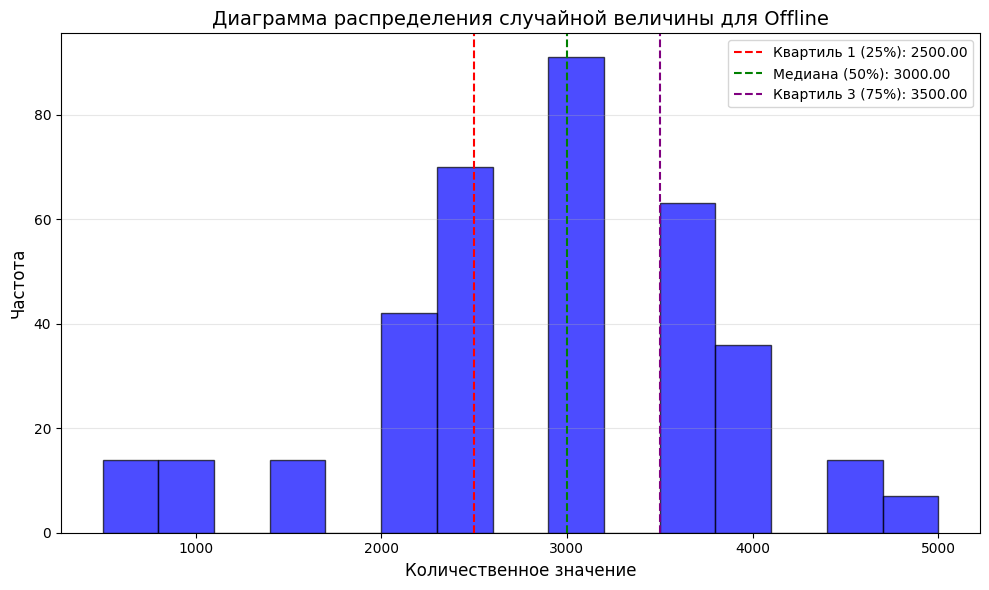

In [62]:
# Создание гистограммы для Offline
plt.figure(figsize=(10, 6))
plt.hist(data_MarketingSpend['Offline'], bins=15, color='blue', alpha=0.7, edgecolor='black')

# Расчет квартилей
quartiles = data_MarketingSpend['Offline'].quantile([0.25, 0.5, 0.75])

# Добавление вертикальных линий для квартилей
colors = ['red', 'green', 'purple']
labels = ['Квартиль 1 (25%)', 'Медиана (50%)', 'Квартиль 3 (75%)']
for q, color, label in zip(quartiles, colors, labels):
    plt.axvline(q, color=color, linestyle='--', linewidth=1.5, label=f'{label}: {q:.2f}')

# Настройка графика
plt.title('Диаграмма распределения случайной величины для Offline', fontsize=14)
plt.xlabel('Количественное значение', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.legend(fontsize=10)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

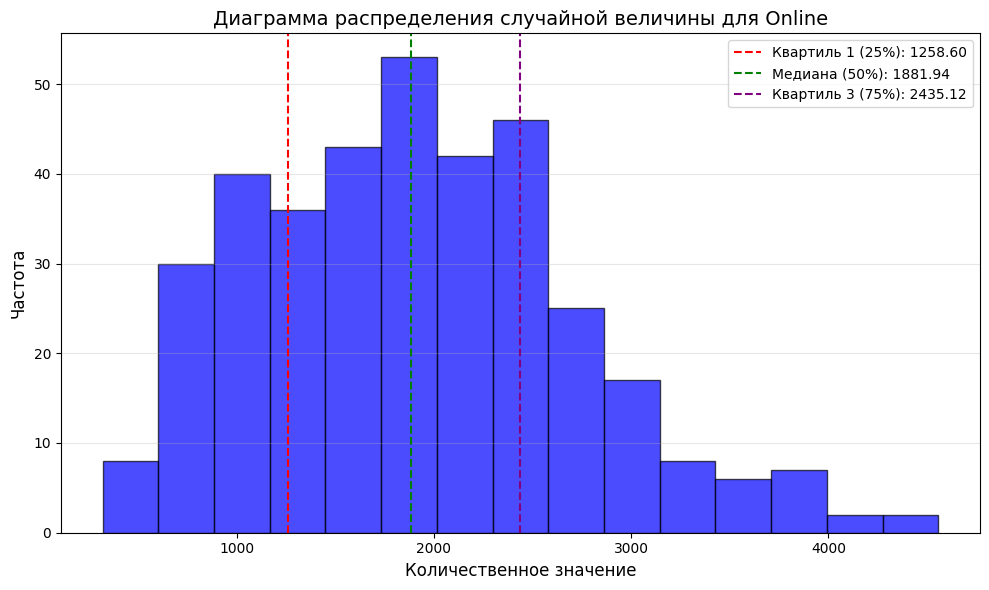

In [63]:
plt.figure(figsize=(10, 6))
plt.hist(data_MarketingSpend['Online'], bins=15, color='blue', alpha=0.7, edgecolor='black')

# Расчет квартилей
quartiles = data_MarketingSpend['Online'].quantile([0.25, 0.5, 0.75])

# Добавление вертикальных линий для квартилей
colors = ['red', 'green', 'purple']
labels = ['Квартиль 1 (25%)', 'Медиана (50%)', 'Квартиль 3 (75%)']
for q, color, label in zip(quartiles, colors, labels):
    plt.axvline(q, color=color, linestyle='--', linewidth=1.5, label=f'{label}: {q:.2f}')

# Настройка графика
plt.title('Диаграмма распределения случайной величины для Online', fontsize=14)
plt.xlabel('Количественное значение', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.legend(fontsize=10)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Задание 1.2.1

In [49]:
data_Retail = pd.read_csv('Retail.csv', header = 0, names = ['InvoiceNo', 'InvoiceDate', 'StockCode', 'Quantity'])

In [56]:
print(f'Всего Инвойсов: {len(data_Retail['InvoiceNo'])}')

Всего Инвойсов: 181247


# Задание 1.2.2

In [57]:
print(f'Всего заказали итемов: {data_Retail['Quantity'].sum()}')

Всего заказали итемов: 826653


# Задание 1.2.3.

In [61]:
print(f'Топ 10 stockcodes, которых заказали наибольшее число раз: {data_Retail['StockCode'].value_counts().head(10)}')

Топ 10 stockcodes, которых заказали наибольшее число раз: StockCode
20725    1549
22197    1357
21212    1325
20727    1281
21931    1162
20728    1145
22086    1083
15056    1070
20724    1022
20726    1009
Name: count, dtype: int64


# Задание 2.1

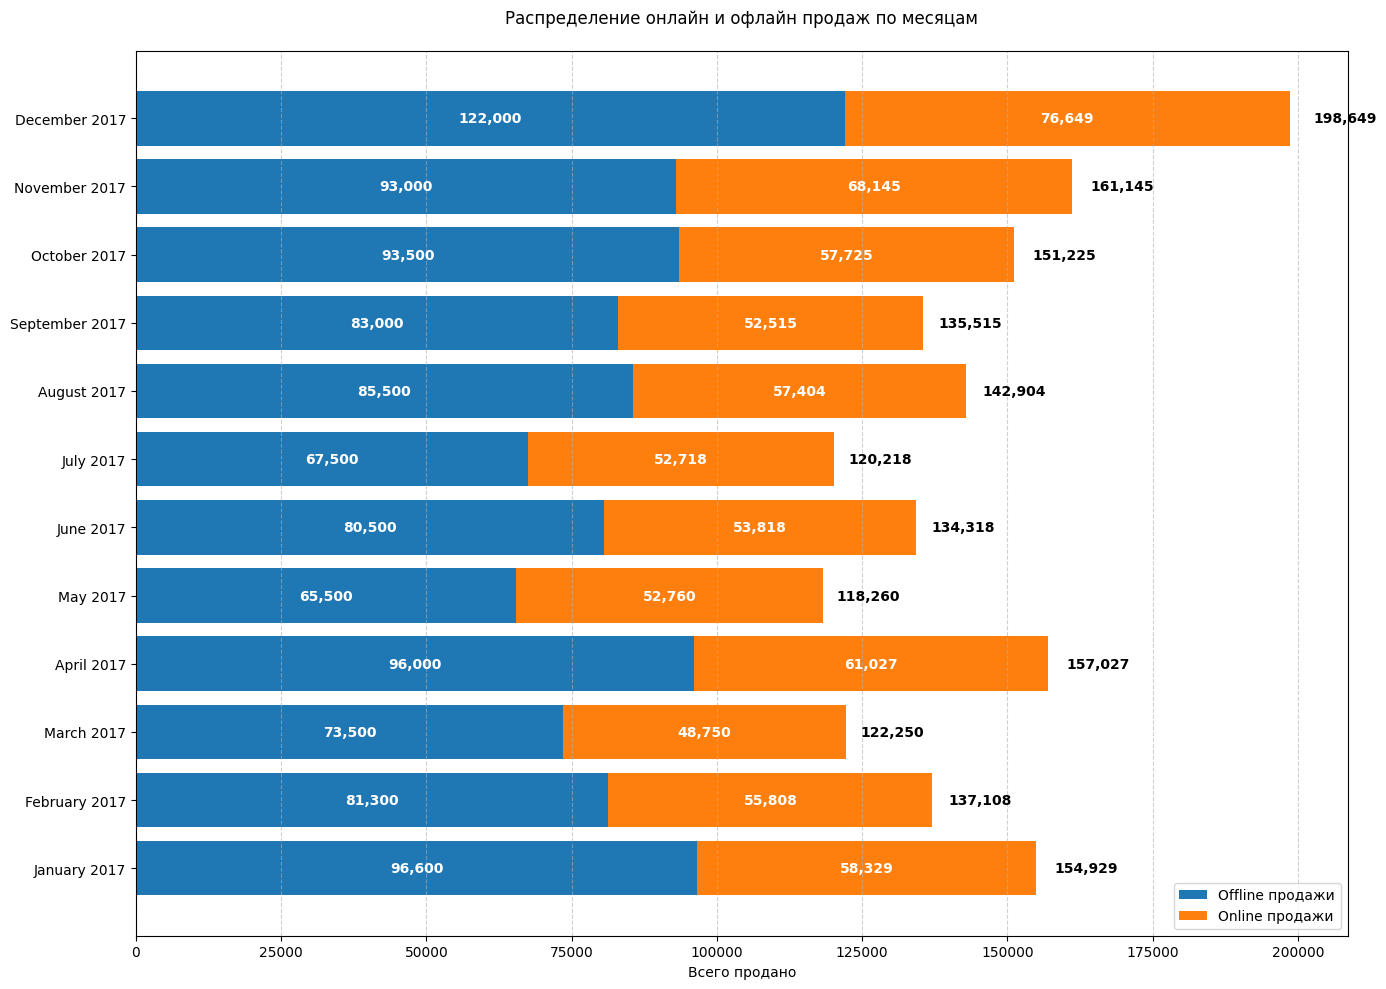

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Загрузка данных
data1 = pd.read_csv('MarketingSpend.csv', parse_dates=[0], index_col=0)

# Группировка по месяцам и суммирование продаж
monthly_data = data1.resample('ME').sum()

# Создание stacked bar plot
fig, ax = plt.subplots(figsize=(14, 10))

colors = ['#1f77b4', '#ff7f0e']  # синий и оранжевый
legend_labels = ['Offline продажи', 'Online продажи']

# Построение stacked bars
offline_bars = ax.barh(
    range(len(monthly_data)),
    monthly_data['Offline Spend'],
    color=colors[0],
    label=legend_labels[0]
)

online_bars = ax.barh(
    range(len(monthly_data)),
    monthly_data['Online Spend'],
    left=monthly_data['Offline Spend'],
    color=colors[1],
    label=legend_labels[1]
)

# Добавление числовых значений на полоски и общих сумм справа
for i, (offline, online) in enumerate(zip(monthly_data['Offline Spend'], monthly_data['Online Spend'])):
    total = offline + online
    # Добавление значений внутри сегментов
    if offline > 0.05 * total:
        ax.text(
            x=offline / 2,
            y=i,
            s=f'{offline:,.0f}',
            ha='center',
            va='center',
            color='white',
            fontweight='bold'
        )
    if online > 0.05 * total:
        ax.text(
            x=offline + online / 2,
            y=i,
            s=f'{online:,.0f}',
            ha='center',
            va='center',
            color='white',
            fontweight='bold'
        )
    # Добавление общей суммы справа от полоски
    ax.text(
        x=total * 1.02,  # небольшой отступ справа от полоски
        y=i,
        s=f'{total:,.0f}',
        ha='left',
        va='center',
        color='black',
        fontweight='bold'
    )

ax.set_yticks(range(len(monthly_data)))
ax.set_yticklabels([date.strftime('%B %Y') for date in monthly_data.index])
ax.set_xlabel('Всего продано')
ax.set_title(
    'Распределение онлайн и офлайн продаж по месяцам',
    pad=20,
    fontsize=12
)
ax.legend(loc='lower right')


plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Задание 2.2

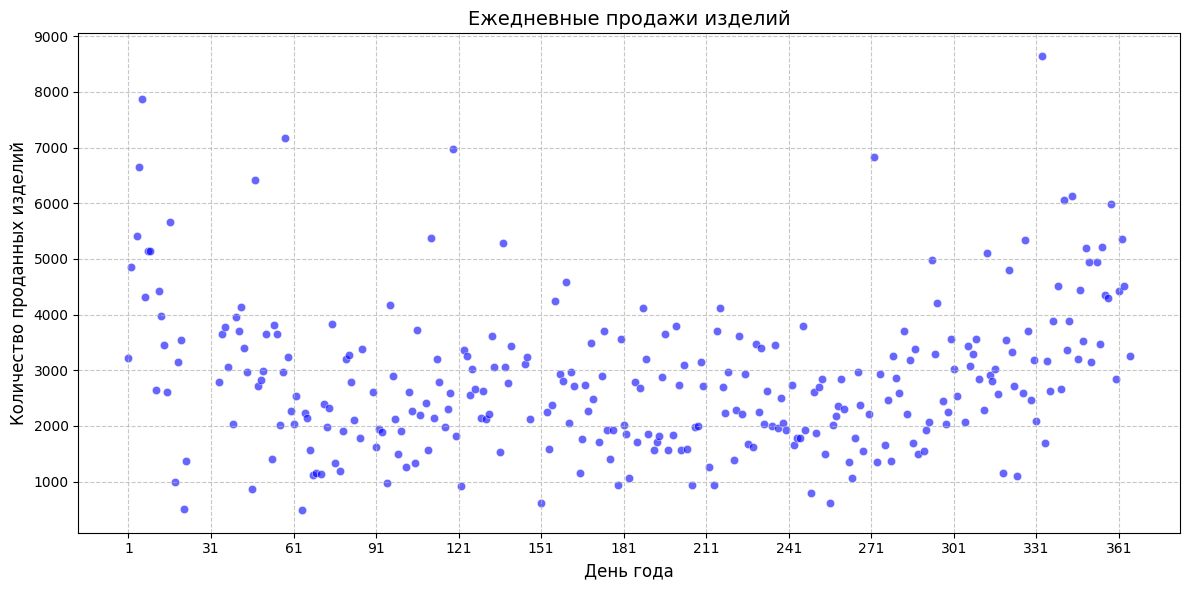

In [68]:
import pandas as pd
import matplotlib.pyplot as plt

# Загрузка данных
data = pd.read_csv('Retail.csv')

# Преобразование даты в формат datetime
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])

# Группировка данных по дате и суммирование количества проданных изделий
daily_sales = data.groupby(data['InvoiceDate'].dt.date)['Quantity'].sum().reset_index()
daily_sales['InvoiceDate'] = pd.to_datetime(daily_sales['InvoiceDate'])
daily_sales['DayOfYear'] = daily_sales['InvoiceDate'].dt.dayofyear

# Создание графика рассеяния
plt.figure(figsize=(12, 6))
plt.scatter(daily_sales['DayOfYear'], daily_sales['Quantity'], color='blue', alpha=0.6, edgecolors='w', linewidth=0.5)

# Настройка осей и заголовка
plt.title('Ежедневные продажи изделий', fontsize=14)
plt.xlabel('День года', fontsize=12)
plt.ylabel('Количество проданных изделий', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Настройка меток оси X (дни года с шагом 30)
plt.xticks(range(1, 366, 30), fontsize=10)
plt.yticks(fontsize=10)

# Отображение графика
plt.tight_layout()
plt.show()